In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_008()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)

session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs

Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.781 s
Baseline,off


Not setting metadata
4200 matching events found
No baseline correction applied
0 projection items activated
combining channels using "gfp"


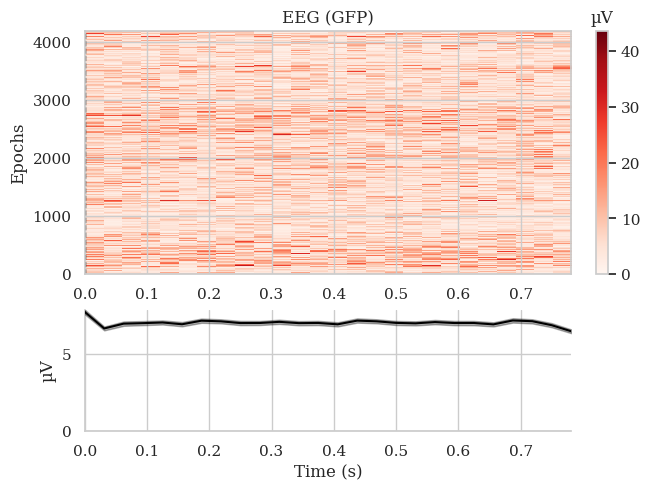

[<Figure size 640x480 with 3 Axes>]

In [4]:
epochs.plot_image()

In [5]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
4195,1,0,0
4196,1,0,0
4197,1,0,0
4198,1,0,0


In [6]:
X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_5040/2444922706.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(4200, 8, 26)

In [42]:
from hoda.hoda import HODA, f_multiway,trunc_eigh
from hoda.cov import ledoit_wolf_shrinkage, oas, mode_scatter, force_toeplitz,center
import warnings


from hoda.hoda import f_oneway, mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
from sklearn.preprocessing import StandardScaler


hoda = HODA(
    rank=3,
    max_iter=32,
    tol=1e-20,
    init ='svd',
    shrinkage='lw',
    toeplitz=None,
    obj='rt',
    solver='lobpcg',
    taper=False,
    extra_train_info=False,
    verbose=False,

)


%lprun -f hoda.fit hoda.fit(X,y)

Timer unit: 1e-09 s

Total time: 0.317384 s
File: /project/src/hoda/hoda.py
Function: fit at line 245

Line #      Hits         Time  Per Hit   % Time  Line Contents
   245                                               def fit(self, X, y):
   246                                                   # Setup
   247         1      27549.0  27549.0      0.0          if not tl.is_tensor(X):
   248         1    2148020.0    2e+06      0.7              X = tl.tensor(X, dtype=X.dtype)
   249                                           
   250         1    2013301.0    2e+06      0.6          self.classes_, class_counts = np.unique(y, return_counts=True)
   251         1     401779.0 401779.0      0.1          class_counts = tl.tensor(class_counts)
   252         1      11431.0  11431.0      0.0          n_samples, *shape = X.shape
   253         1       3021.0   3021.0      0.0          order = len(shape)
   254                                           
   255                                      

In [8]:
hoda.train_info_

,iteration,mode,update,shrinkage,objective,F_tr,F_rt,mse,log_like,bic,aic,aicc
0,0.0,0.0,1.843844e-01,0.000300,1.981447e-07,0.000651,0.000005,5.288802e-11,-1880.648199,3836.381956,3779.296398,3779.339358
1,0.0,1.0,5.153042e-02,0.022156,2.920572e-07,0.001975,0.000013,6.411033e-11,-1861.074350,3797.234258,3740.148700,3740.191659
2,1.0,0.0,1.007806e-01,0.000378,2.299982e-07,0.034154,0.000094,6.736370e-11,-1672.833120,3420.751798,3363.666239,3363.709199
3,1.0,1.0,5.523266e-03,0.010024,3.145100e-07,0.051741,0.000172,6.698471e-11,-1515.438407,3105.962371,3048.876813,3048.919773
4,2.0,0.0,5.573138e-02,0.000305,2.033400e-07,0.068700,0.000216,6.759152e-11,-1430.780851,2936.647260,2879.561701,2879.604661
5,2.0,1.0,5.817171e-05,0.007947,3.331735e-07,0.067730,0.000229,6.879331e-11,-1408.846532,2892.778623,2835.693064,2835.736024
6,3.0,0.0,2.253869e-04,0.000305,2.023046e-07,0.067804,0.000231,6.876998e-11,-1404.914453,2884.914463,2827.828905,2827.871864
7,3.0,1.0,1.709420e-02,0.007908,3.372373e-07,0.066610,0.000231,6.881486e-11,-1403.773908,2882.633374,2825.547816,2825.590775
8,4.0,0.0,2.399800e-12,0.000306,2.023069e-07,0.066610,0.000231,6.881486e-11,-1403.766206,2882.617971,2825.532413,2825.575372
9,4.0,1.0,3.360379e-14,0.007908,3.372366e-07,0.066609,0.000231,6.881485e-11,-1403.766507,2882.618573,2825.533014,2825.575974


<Axes: xlabel='iteration', ylabel='objective'>

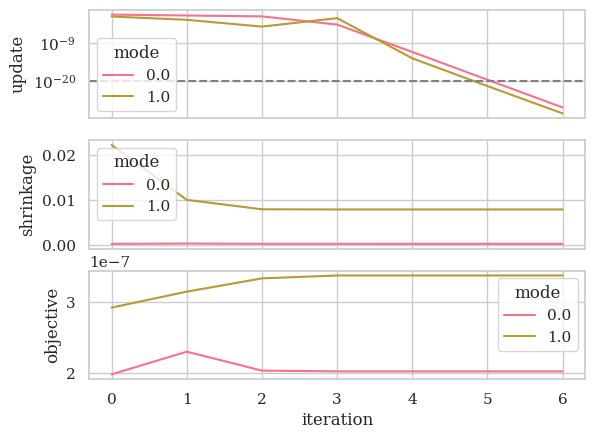

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, axs = plt.subplots(3,1, sharex=True)
sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='shrinkage',hue='mode', ax=axs[1])
sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='objective',hue='mode', ax=axs[2])


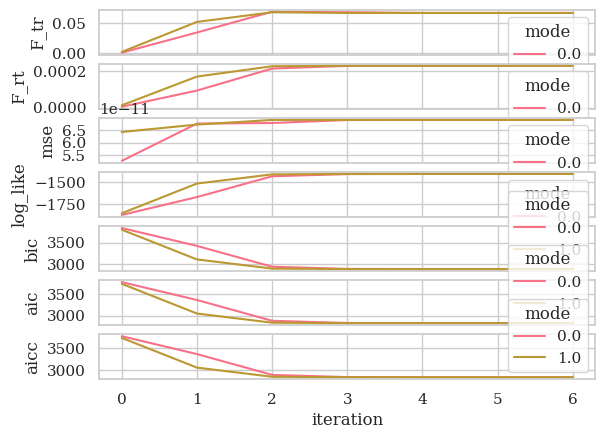

In [10]:
if hoda.extra_train_info:
    fig, axs = plt.subplots(7,1, sharex=True)
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_tr', hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_rt', hue='mode', ax=axs[1])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='mse', hue='mode', ax=axs[2])
    #axs[2].set(yscale="log")
    #axs[2].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='log_like', hue='mode', ax=axs[3])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='bic', hue='mode', ax=axs[4])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='aic', hue='mode', ax=axs[5]) 
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='aicc', hue='mode', ax=axs[6])



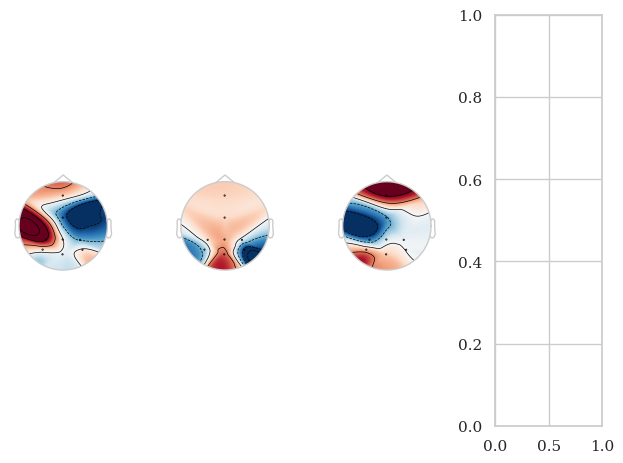

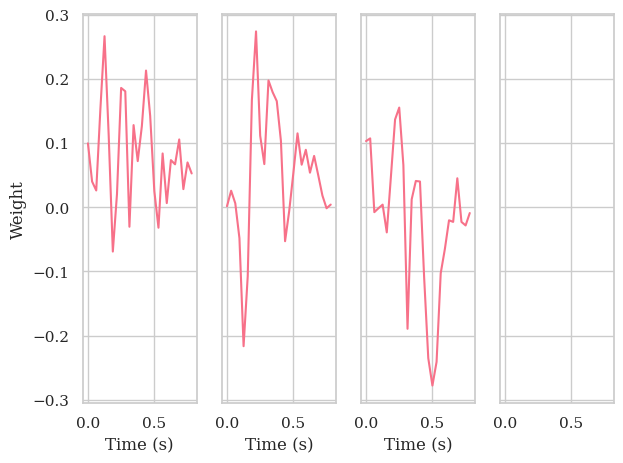

In [11]:

import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl


col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_(0)):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_(1)):
    w = tl.to_numpy(hoda.weights_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


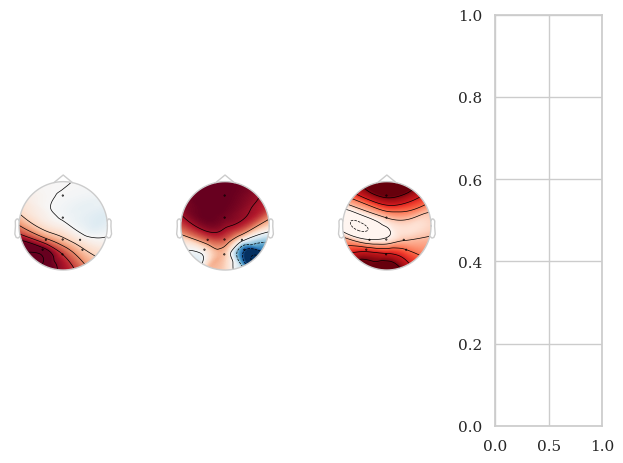

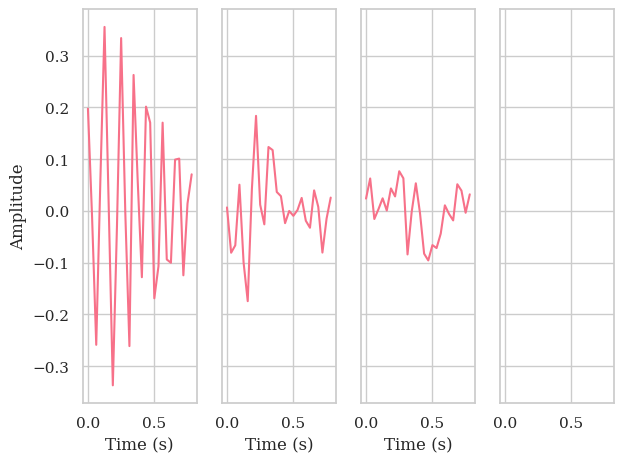

In [12]:

n_row = int(np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_(0)):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_(1)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude');


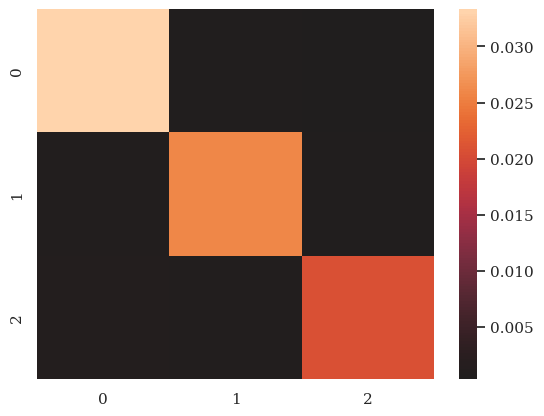

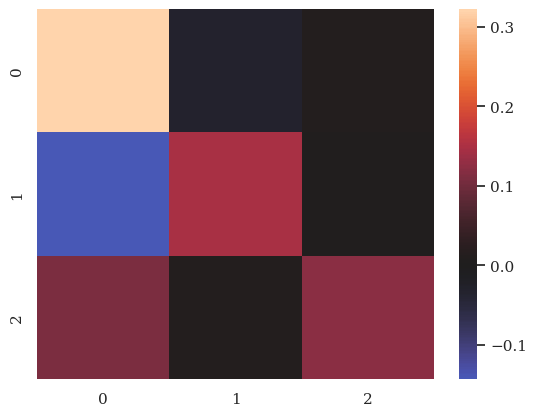

In [13]:
for k in range(2):
    sns.heatmap(tl.to_numpy(hoda.weights_[k].T@ hoda.aps_[k]), center=0)
    plt.show()


In [14]:
Xt = hoda.transform(X)

In [15]:
from hoda.hoda import f_multiway
"""
F, p = f_oneway(Xt,y)

classes = np.unique(y)
y_like_Xt = tl.zeros_like(Xt)
for ci, c in enumerate(classes):
    y_like_Xt[y==c] = ci


F_sp, p_sp = f_oneway(tl.unfold(Xt, 0+1).T, tl.unfold(y_like_Xt, 0+1).T[:,0])
F_tmp, p_tmp = f_oneway(tl.unfold(Xt, 1+1).T, tl.unfold(y_like_Xt, 1+1).T[:,0])


F_sp = tl.to_numpy(F_sp)
F_tmp = tl.to_numpy(F_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)

g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.05/p.size,cbar=False, cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, F_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, F_sp)

print(p)
print()
print(p_sp)
print()
print(p_tmp)
"""

"\nF, p = f_oneway(Xt,y)\n\nclasses = np.unique(y)\ny_like_Xt = tl.zeros_like(Xt)\nfor ci, c in enumerate(classes):\n    y_like_Xt[y==c] = ci\n\n\nF_sp, p_sp = f_oneway(tl.unfold(Xt, 0+1).T, tl.unfold(y_like_Xt, 0+1).T[:,0])\nF_tmp, p_tmp = f_oneway(tl.unfold(Xt, 1+1).T, tl.unfold(y_like_Xt, 1+1).T[:,0])\n\n\nF_sp = tl.to_numpy(F_sp)\nF_tmp = tl.to_numpy(F_tmp)\nF = tl.to_numpy(F)\np= tl.to_numpy(p)\n\ng = sns.JointGrid()\nsns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.05/p.size,cbar=False, cmap='Blues')\ng.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, F_tmp)\ng.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, F_sp)\n\nprint(p)\nprint()\nprint(p_sp)\nprint()\nprint(p_tmp)\n"

In [16]:
from sklearn.feature_selection import SelectFwe

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))
Xt_flat.shape

(4200, 9)

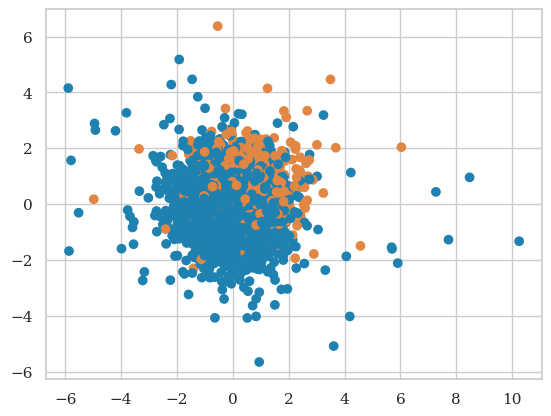

In [17]:

from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))

if Xt_flat.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_flat))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')

No projector specified for this dataset. Please consider the method self.add_proj.


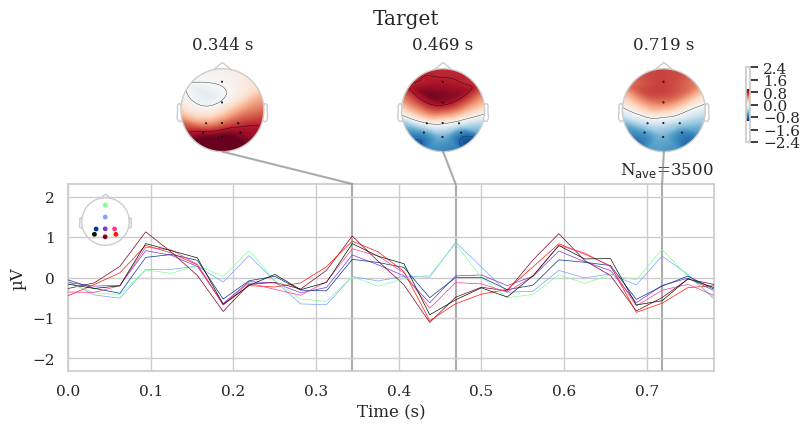

No projector specified for this dataset. Please consider the method self.add_proj.


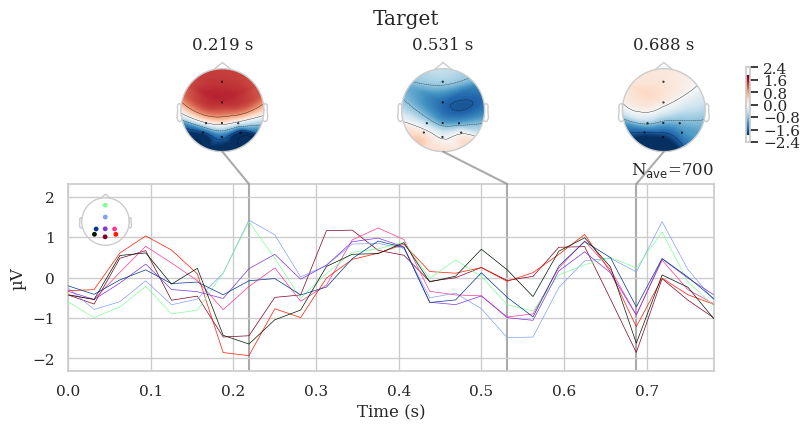

In [18]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

for evoked  in evokeds:
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


/tmp/ipykernel_5040/286715887.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))


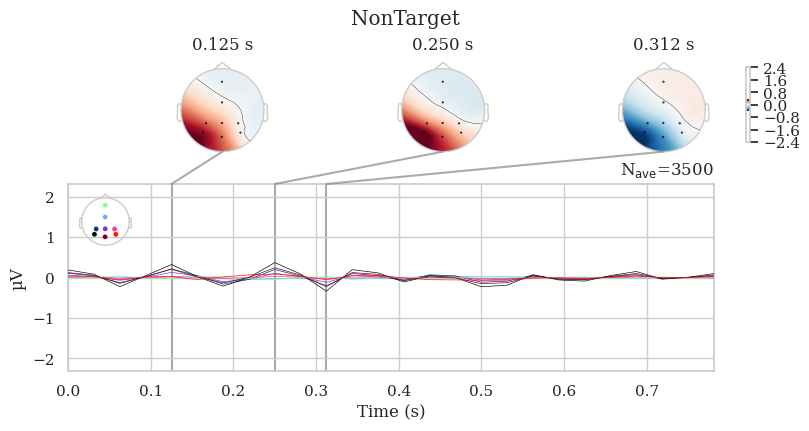

No projector specified for this dataset. Please consider the method self.add_proj.


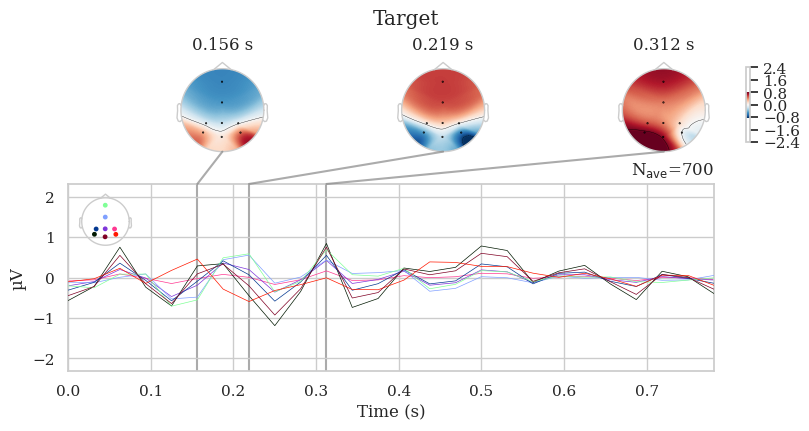

In [19]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.plot_joint(title=cls,**joint_args)
    else:
        evoked_rec.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


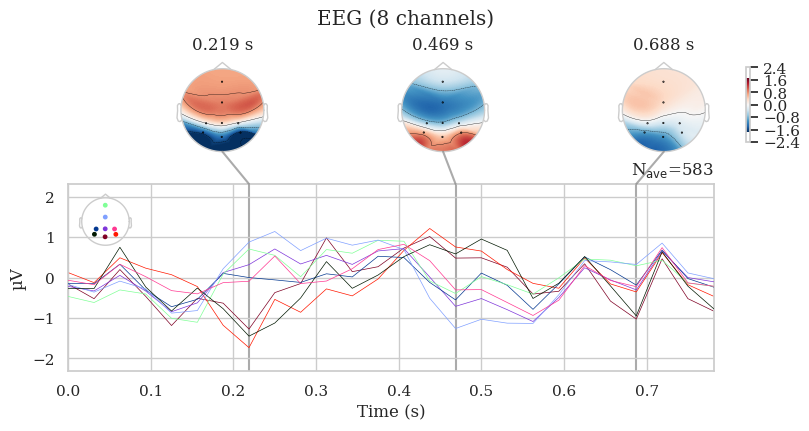

No projector specified for this dataset. Please consider the method self.add_proj.


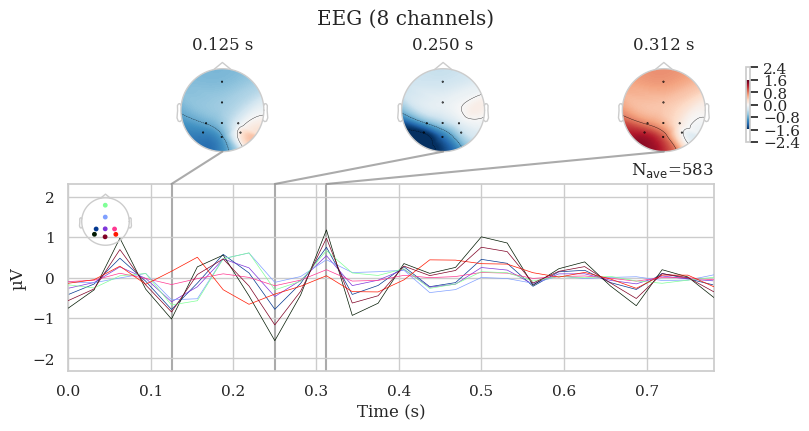

In [20]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


No projector specified for this dataset. Please consider the method self.add_proj.


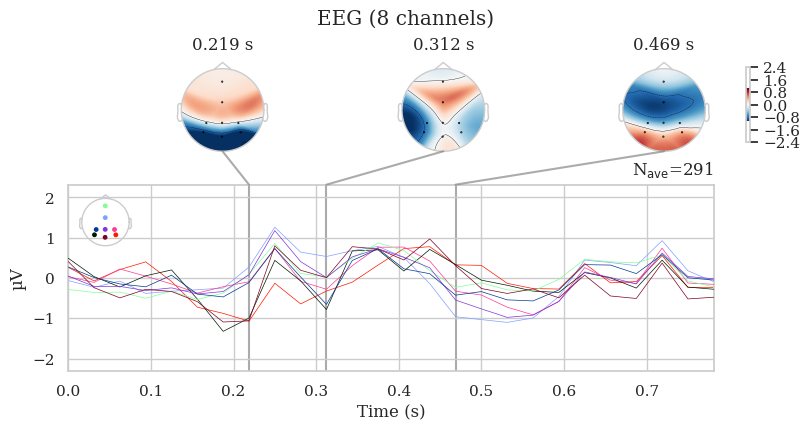

In [21]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)